In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

from keras.preprocessing import image

In [3]:
import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Prodigy infotech/food'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print("✅ Dataset Loaded Successfully")

/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (12).jpg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (1).jpeg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (13).jpeg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (13).jpg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (14).jpg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (11).jpeg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (15).jpeg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (10).jpeg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (1).jpg
/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Aloo Paratha/Paratha (14).jpeg
/content/drive/MyDrive/Prodigy infotech/food/I

In [6]:
image_dir = Path('/content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset')
filepaths = list(image_dir.glob(r'**/*.jpg'))
#using glob to target particular image files

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
#separating the class names from the file paths and saving in labels

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

category_samples = []
for category in images['Label'].unique():
    category_slice = images.query("Label == @category")
    # Sample at most the number of available images for the category
    sample_size = min(130, len(category_slice))
    category_samples.append(category_slice.sample(sample_size, random_state=1))
#concatenate category samples
image_df = pd.concat(category_samples, axis=0).sample(frac=1.0, random_state=1).reset_index(drop=True)

In [7]:
image_df['Label'].value_counts()

,count
Label,
Puran Poli,109
Samosa,77
Aloo Paratha,77
Dosa,72
Dhokla,58
Idli,28
Malai Kofta,25


In [8]:
train_df, test_df = train_test_split(image_df, train_size=0.7, shuffle=True, random_state=1)

In [9]:
#limited memory so we train in batches to recycle memory
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [10]:
#this train_images will be passed into our fit function
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
#default image size for mobilenetV2 is 224x224
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
#shuffle after each epoch
    seed=42,
    subset='training'
#only available if validation_split is used to specify whether to use validation subset 0.2 or training subset

)

validation_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 250 validated image filenames belonging to 7 classes.
Found 62 validated image filenames belonging to 7 classes.
Found 134 validated image filenames belonging to 7 classes.


In [11]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,

    weights='imagenet',
#to keep the same weights
    pooling='avg'
#output is 1d now
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
#128 neurons
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(7, activation='softmax')(x)
#classification layer
model = tf.keras.Model(inputs, outputs)


print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,439,367 (9.31 MB)

 Trainable params: 181,383 (708.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [19]:
history = model.fit(
    train_images,
    validation_data=validation_images,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='validation_loss',
            patience=3,
            mode='min',
            restore_best_weights=True
        )
    ]
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.7787 - loss: 0.7339 - val_accuracy: 0.6774 - val_loss: 0.8185
Epoch 2/10


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `validation_loss` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9557 - loss: 0.2918 - val_accuracy: 0.8065 - val_loss: 0.5385
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9519 - loss: 0.1452 - val_accuracy: 0.8226 - val_loss: 0.5307
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9901 - loss: 0.0642 - val_accuracy: 0.7742 - val_loss: 0.5637
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 1.0000 - loss: 0.0340 - val_accuracy: 0.8226 - val_loss: 0.4806
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.8226 - val_loss: 0.4453
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 1.0000 - loss: 0.0117 - val_accuracy: 0.8226 - val_loss: 0.4873
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.8065 - val_loss: 0.4798
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8065 - val_loss: 0.5032
Epoch 10/10
8/8 ━━━

In [20]:
results = model.evaluate(test_images, verbose=0)
#gives loss and accuracy for test set
print("Test Accuracy: {:.2f}%".format(results[1] * 100))


Test Accuracy: 88.06%


In [22]:
predictions = np.argmax(model.predict(test_images), axis=1)

cm = confusion_matrix(test_images.labels, predictions)
clr = classification_report(test_images.labels, predictions, target_names=test_images.class_indices, zero_division=0)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


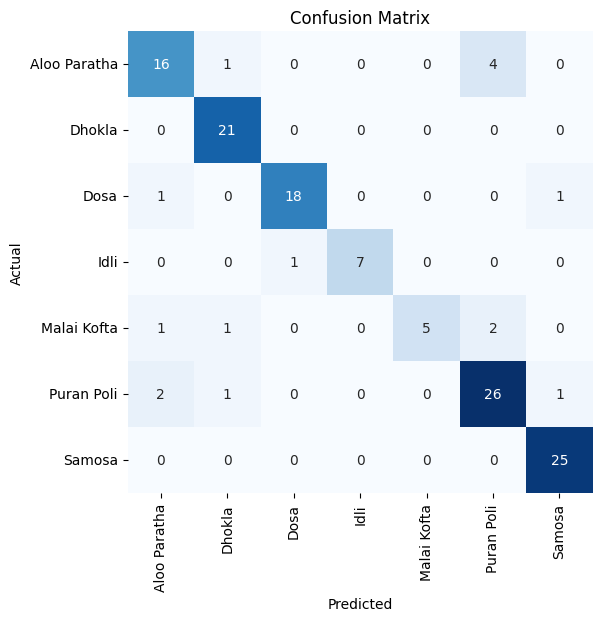

In [24]:
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
plt.xticks(ticks=np.arange(len(test_images.class_indices)) + 0.5, labels=test_images.class_indices, rotation=90)
plt.yticks(ticks=np.arange(len(test_images.class_indices)) + 0.5, labels=test_images.class_indices, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print("Classification Report:\n----------------------\n", clr)

Classification Report:
----------------------
               precision    recall  f1-score   support

Aloo Paratha       0.80      0.76      0.78        21
      Dhokla       0.88      1.00      0.93        21
        Dosa       0.95      0.90      0.92        20
        Idli       1.00      0.88      0.93         8
 Malai Kofta       1.00      0.56      0.71         9
  Puran Poli       0.81      0.87      0.84        30
      Samosa       0.93      1.00      0.96        25

    accuracy                           0.88       134
   macro avg       0.91      0.85      0.87       134
weighted avg       0.89      0.88      0.88       134



Predicted Dish: samosa


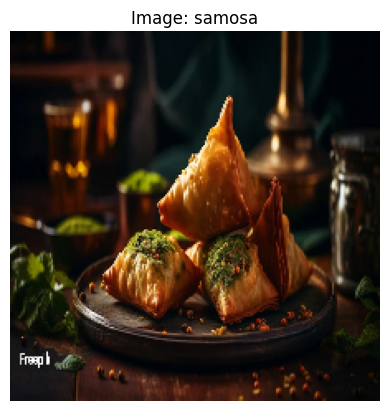

In [42]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np



file_path = '../content/drive/MyDrive/Prodigy infotech/food/Indian Food Dataset/Samosa/Samosa (1).jpg'

def read_image(file_path):
    image = load_img(file_path, target_size=(224, 224))

    display_image = image.copy()
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image /= 255.
    return image, display_image

image_for_prediction, original_image_for_display = read_image(file_path)


class DummyModel:
    def predict(self, image):

        return np.array([[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.99]])

model = DummyModel()

predictions = np.argmax(model.predict(image_for_prediction), axis=1)
dishes = ['Aloo Paratha','Dhokla', 'Dosa', 'Idli', 'Malai Kofta', 'Puran Poli', 'samosa']

predicted_dish = dishes[predictions[0]]
print(f"Predicted Dish: {predicted_dish}")

# --- Code to display the image ---
plt.imshow(original_image_for_display)
plt.title(f"Image: {predicted_dish}")
plt.axis('off')
plt.show()